In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
os.environ["KERAS_BACKEND"] = "torch"
import keras
print(keras.backend.backend())
from keras.models import Sequential
from keras.optimizers import Adam
from keras.layers import Convolution2D, MaxPooling2D, Dropout, Flatten, Dense
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
import albumentations as A
import cv2
import pandas as pd
import random
import ntpath

torch


In [2]:
data_dir = 'sim_data'
columns = ['rgb', 'mask', 'steering']
data = pd.read_csv(os.path.join(data_dir, 'driving_log.csv'), names=columns)
pd.set_option('display.max_colwidth', None)
data.head()

,rgb,mask,steering
0,rgb,mask,steering
1,driving_model/sim_data/RGB\00000.png,driving_model/sim_data/masks\00000.png,0.0
2,driving_model/sim_data/RGB\00001.png,driving_model/sim_data/masks\00001.png,0.0
3,driving_model/sim_data/RGB\00002.png,driving_model/sim_data/masks\00002.png,0.0
4,driving_model/sim_data/RGB\00003.png,driving_model/sim_data/masks\00003.png,0.0


In [3]:
def path_leaf(path):
    head, tail = ntpath.split(path)
    return tail
data['rgb'] = data['rgb'].apply(path_leaf)
data['mask'] = data['mask'].apply(path_leaf)

data.head()

,rgb,mask,steering
0,rgb,mask,steering
1,00000.png,00000.png,0.0
2,00001.png,00001.png,0.0
3,00002.png,00002.png,0.0
4,00003.png,00003.png,0.0


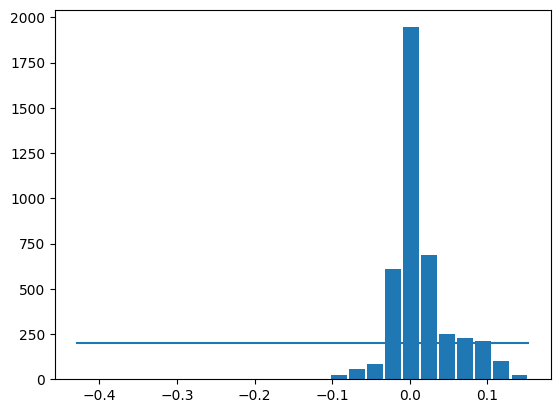

In [4]:
data['steering'] = pd.to_numeric(data['steering'], errors='coerce')
data = data.dropna(subset=['steering'])
num_bins = 25
samples_per_bin = 200
hist, bins = np.histogram(data['steering'], num_bins)
center = (bins[:-1] + bins[1:]) * 0.5
plt.bar(center, hist, width=0.02)
plt.plot((np.min(data['steering']), np.max(data['steering'])), (samples_per_bin, samples_per_bin))

length of data 4231
removed 2732
remaining data 1499


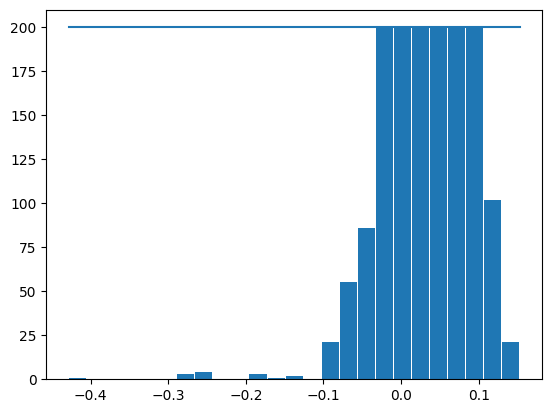

In [5]:
print(f"length of data {len(data)}")
remove_list = []

for j in range(num_bins):
    list_ = []
    for i in range(len(data['steering'])):
        if data['steering'].iloc[i] >= bins[j] and data['steering'].iloc[i] <= bins[j+1]:
            list_.append(i)
    list_ = shuffle(list_)
    list_ = list_[samples_per_bin:]
    remove_list.extend(list_)

print(f'removed {len(remove_list)}')
data.drop(data.index[remove_list], inplace=True)
print(f'remaining data {len(data)}')

hist, _ = np.histogram(data['steering'], (num_bins))
plt.bar(center, hist, width=0.022)
plt.plot((np.min(data['steering']), np.max(data['steering'])), (samples_per_bin, samples_per_bin))

In [25]:
print(data.iloc[1])
def load_img_mask_steering(rgb_dir, mask_dir, df):
    rgb_path = []
    mask_path = []
    steering = []
    for i in range(len(data)):
        indexed_data = data.iloc[i]
        rgb = indexed_data[0]
        mask = indexed_data[1]
        rgb_path.append(os.path.join(rgb_dir, rgb.strip()))
        mask_path.append(os.path.join(mask_dir, mask.strip()))
        steering.append(float(indexed_data[2]))
    rgb_paths = np.asarray(rgb_path)
    maks_paths = np.asarray(mask_path)
    steerings = np.asarray(steering)

    return rgb_paths, maks_paths, steerings

rgb_paths, mask_paths, steerings = load_img_mask_steering(data_dir + '/RGB', data_dir + '/masks', data)

rgb         00017.png
mask        00017.png
steering     0.041258
Name: 18, dtype: object


C:\Users\Kanumuri\AppData\Local\Temp\ipykernel_17976\185578654.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  rgb = indexed_data[0]
C:\Users\Kanumuri\AppData\Local\Temp\ipykernel_17976\185578654.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  mask = indexed_data[1]
C:\Users\Kanumuri\AppData\Local\Temp\ipykernel_17976\185578654.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  steering.append(float(indexed_data[2]))


In [26]:
rgb_train, rgb_valid, mask_train, mask_valid, steer_train, steer_valid = train_test_split(rgb_paths, mask_paths, steerings, test_size=0.2, random_state=6)
print(f"Training Samples: {len(rgb_train)}\nValid Samples: {len(rgb_valid)}")

Training Samples: 1199
Valid Samples: 300


Text(0.5, 1.0, 'Validation Set')

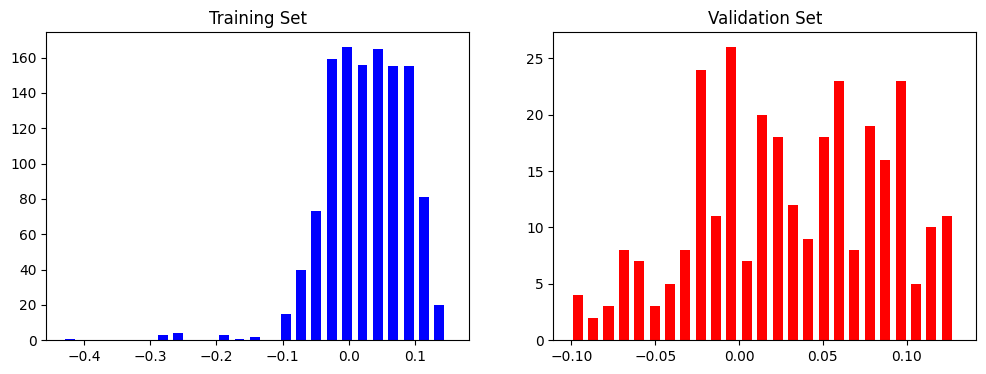

In [27]:
fix, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(steer_train, bins=num_bins, width=0.015, color='blue')
axes[0].set_title('Training Set')
axes[1].hist(steer_valid, bins=num_bins, width=0.006, color='red')
axes[1].set_title('Validation Set')

In [39]:
def zoom(img, mask):
    zoom = A.Compose(
        [A.Affine(scale=(1.0, 1.3))],
        additional_targets={"mask" : "mask"}
    )
    augmented = zoom(image=img, mask=mask)
    return augmented["image"], augmented["mask"]

Text(0.5, 1.0, 'Zoomed Mask')

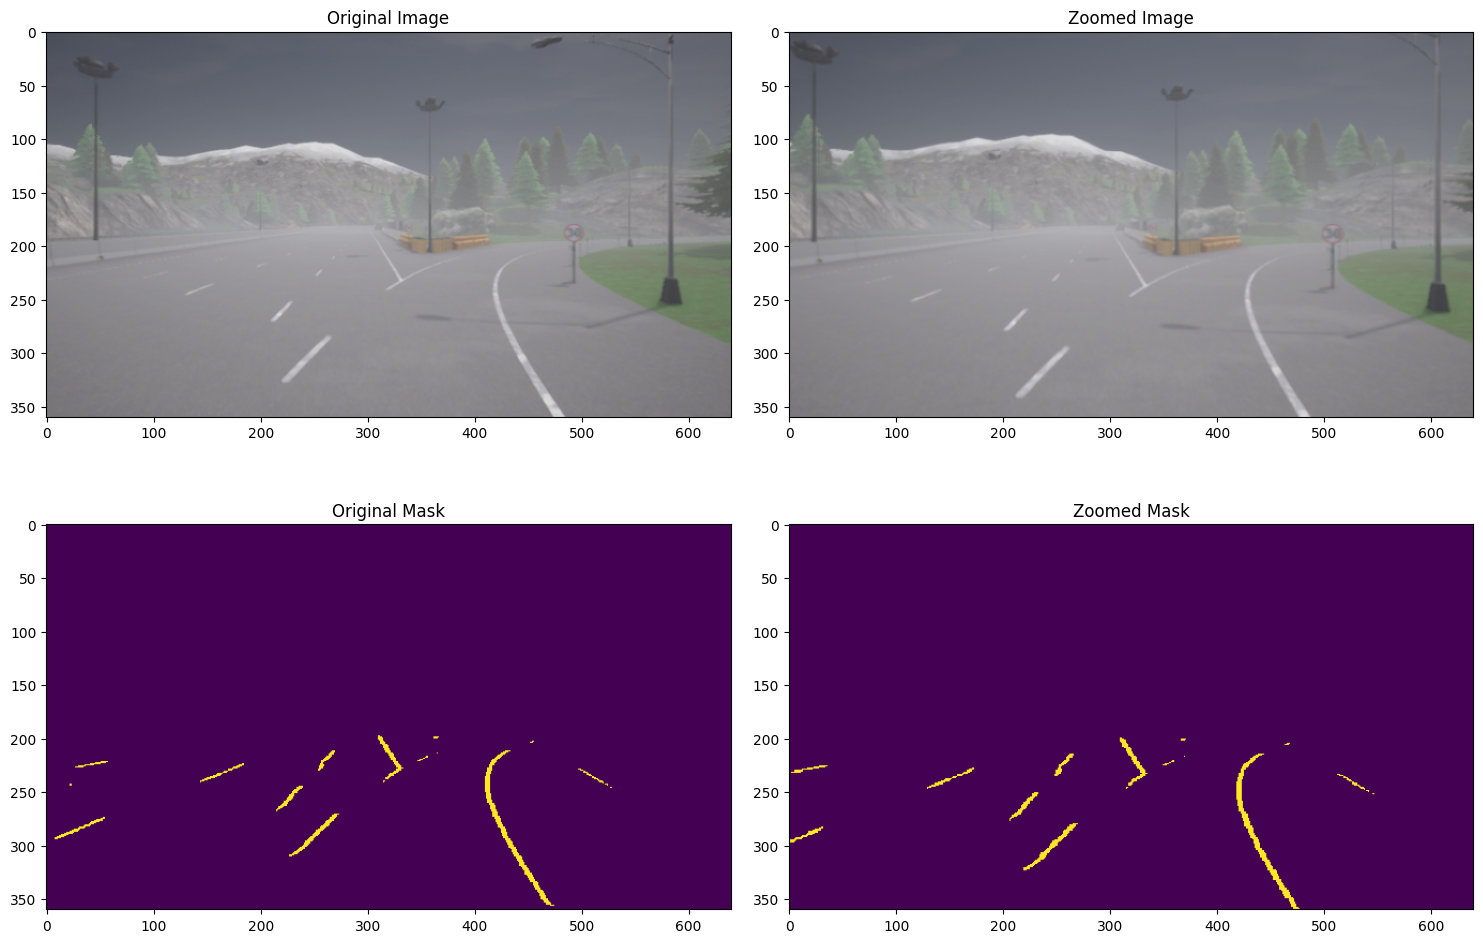

In [42]:
random_index = random.randint(0, 1000)
image = rgb_paths[random_index]
mask = mask_paths[random_index]

original_image = mpimg.imread(image)
original_mask = mpimg.imread(mask)

zoomed_image, zoomed_mask = zoom(original_image, original_mask)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.tight_layout()
axes[0][0].imshow(original_image)
axes[0][0].set_title('Original Image')
axes[0][1].imshow(zoomed_image)
axes[0][1].set_title('Zoomed Image')
axes[1][0].imshow(original_mask)
axes[1][0].set_title('Original Mask')
axes[1][1].imshow(zoomed_mask)
axes[1][1].set_title('Zoomed Mask')

In [95]:
def pan(img, mask):
    pan = A.Compose(
        [A.Affine(translate_percent={"x" : (-0.1, 0.1), "y" : (-0.1, 0.1)})],
        additional_targets={"mask" : "mask"}
    )
    augmented = pan(image=img, mask=mask)
    return augmented["image"], augmented["mask"]

Text(0.5, 1.0, 'Panned Mask')

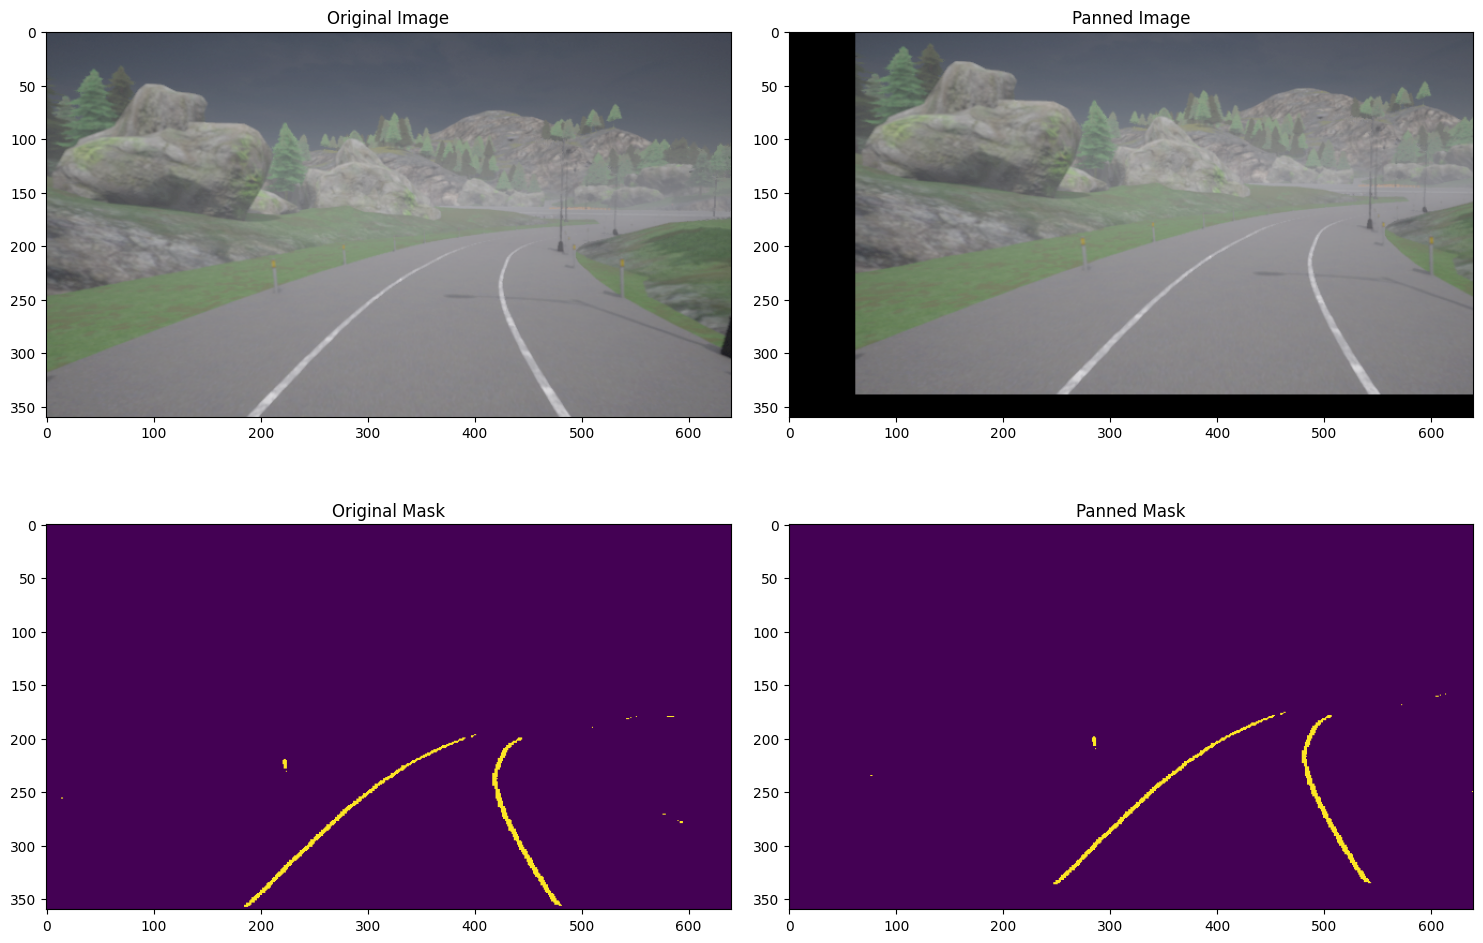

In [99]:
random_index = random.randint(0, 1000)
image = rgb_paths[random_index]
mask = mask_paths[random_index]

original_image = mpimg.imread(image)
original_mask = mpimg.imread(mask)

panned_image, panned_mask = pan(original_image, original_mask)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.tight_layout()
axes[0][0].imshow(original_image)
axes[0][0].set_title('Original Image')
axes[0][1].imshow(panned_image)
axes[0][1].set_title('Panned Image')
axes[1][0].imshow(original_mask)
axes[1][0].set_title('Original Mask')
axes[1][1].imshow(panned_mask)
axes[1][1].set_title('Panned Mask')

In [89]:
def img_random_brightness(img):
    brightness = A.RandomBrightnessContrast(
    brightness_limit=0.2,
    contrast_limit=0.0,
    p=1.0)

    augmented = brightness(image=img)
    return augmented["image"]

Text(0.5, 1.0, 'Brightness Altered Image')

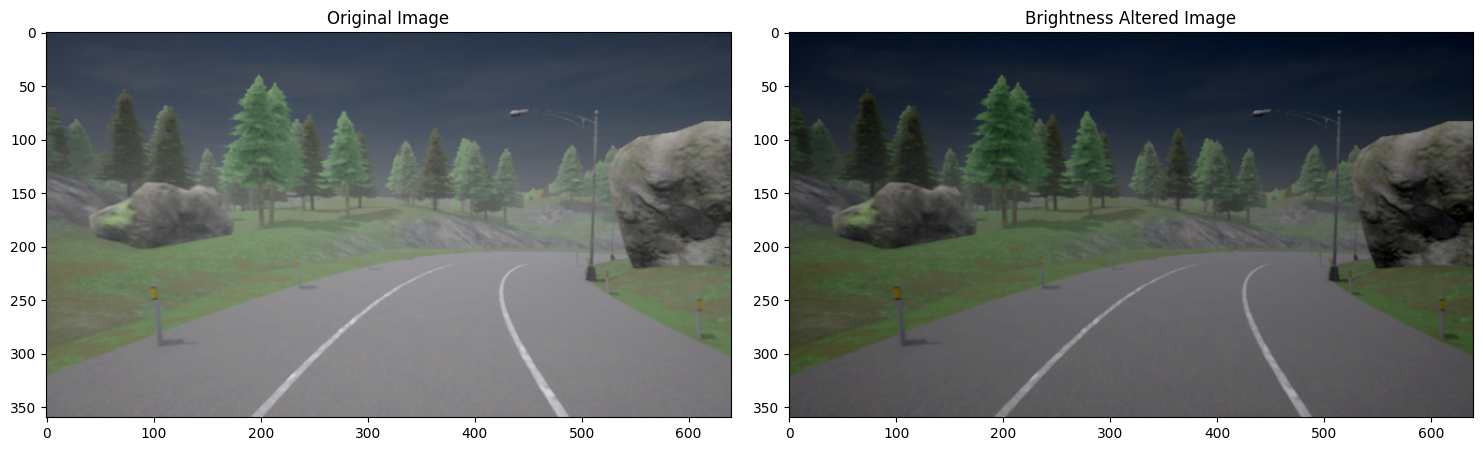

In [94]:
random_index = random.randint(0, 1000)
image = rgb_paths[random_index]

original_image = mpimg.imread(image)
brightness_altered_img = img_random_brightness(original_image)

fig, axes = plt.subplots(1, 2, figsize=(15, 10))
fig.tight_layout()
axes[0].imshow(original_image)
axes[0].set_title('Original Image')
axes[1].imshow(brightness_altered_img)
axes[1].set_title('Brightness Altered Image')

In [100]:
def img_random_flip(img, mask, steering_angle):
    img = cv2.flip(img, 1)
    mask = cv2.flip(mask, 1)
    steering_angle = -steering_angle
    return img, mask, steering_angle

Text(0.5, 1.0, 'Flipped Mask')

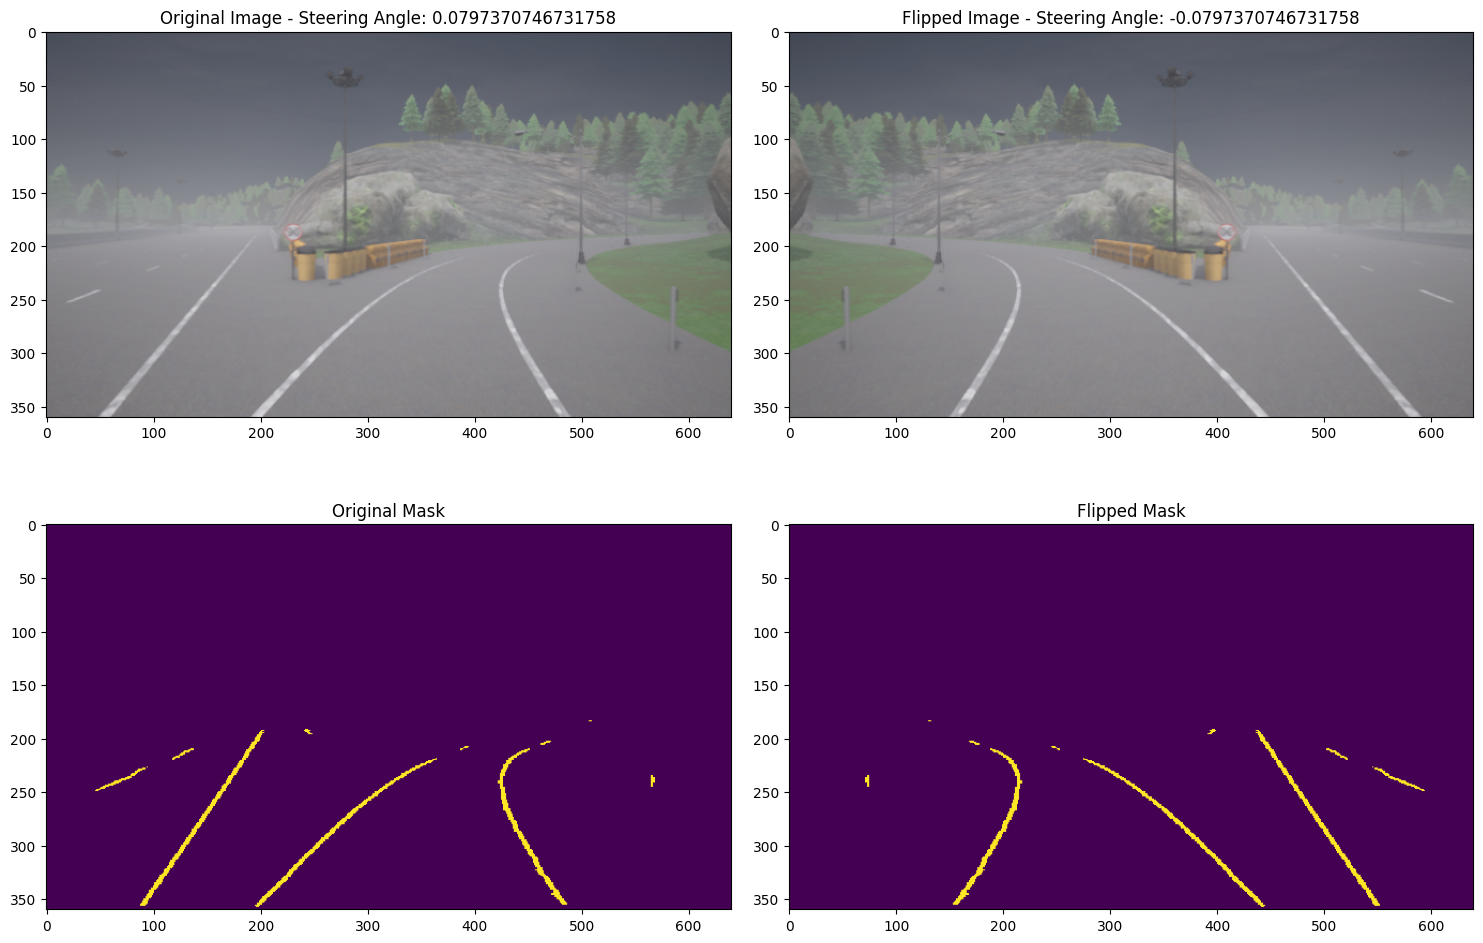

In [106]:
random_index = random.randint(0, 1000)
image = rgb_paths[random_index]
mask = mask_paths[random_index]
steering_angle = steerings[random_index]

original_image = mpimg.imread(image)
original_mask = mpimg.imread(mask)

flipped_image, flipped_mask, flipped_steering = img_random_flip(original_image, original_mask, steering_angle)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.tight_layout()
axes[0][0].imshow(original_image)
axes[0][0].set_title('Original Image - Steering Angle: ' + str(steering_angle))
axes[0][1].imshow(flipped_image)
axes[0][1].set_title('Flipped Image - Steering Angle: ' + str(flipped_steering))
axes[1][0].imshow(original_mask)
axes[1][0].set_title('Original Mask')
axes[1][1].imshow(flipped_mask)
axes[1][1].set_title('Flipped Mask')